In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor 
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)


2.11.0
0.26.0


In [2]:
#Getting a dataset:
#Fashion MNIST


train_data  = datasets.FashionMNIST(
    root= "data",
    train= True,
    download= True,
    transform = torchvision.transforms.ToTensor(),
    target_transform=None
)

test_data  = datasets.FashionMNIST(
    root= "data",
    train= False,
    download= True,
    transform = torchvision.transforms.ToTensor(),
    target_transform=None
)


In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
image, label = train_data[0]


In [5]:
classes = train_data.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
classtoidx = train_data.class_to_idx
classnames = train_data.classes

In [7]:
classtoidx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [8]:
print(f"image shape: {image.shape}")

image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, 'Ankle boot')

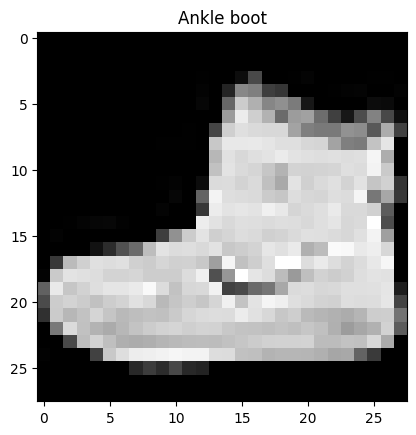

In [9]:
import matplotlib.pyplot as plt
plt.imshow(image.squeeze(), cmap= "gray")
plt.title(classnames[label])


37542
46067
46876
46414
10026
27335
38620
11924
14950
57113
31378
29014
47210
18954
18231
47572


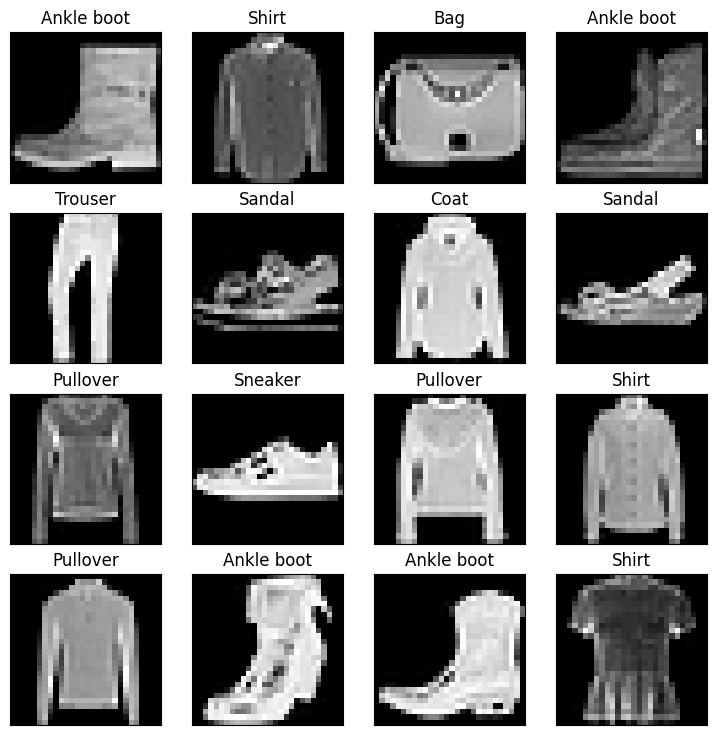

In [10]:
from matplotlib.pyplot import xticks
torch.manual_seed(42)
fig = plt.figure(figsize= (9,9) )
rows, cols = 4,4
for i in range(1, rows*cols+1):
    random_idx = torch.randint(0, len(train_data), size = [1]).item()
    print(random_idx)
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.title(classnames[label])
    plt.imshow(img.squeeze(), cmap="gray")
    plt.xticks([])
    plt.yticks([])

In [11]:
from torch.utils.data import DataLoader

BATCHSIZE = 32

train_dataloader=DataLoader(dataset=train_data, batch_size=BATCHSIZE, shuffle= True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCHSIZE, shuffle= False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x1171bb9d0>,
 <torch.utils.data.dataloader.DataLoader at 0x1176ba510>)

In [12]:
print(f'dataloaders : {train_dataloader, test_dataloader}')
print(f'Len : {len(train_dataloader)}, {len(test_dataloader)}')

dataloaders : (<torch.utils.data.dataloader.DataLoader object at 0x1171bb9d0>, <torch.utils.data.dataloader.DataLoader object at 0x1176ba510>)
Len : 1875, 313


In [13]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape

torch.Size([32, 1, 28, 28])

In [14]:
from torch import randint
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]

46067


([], [])

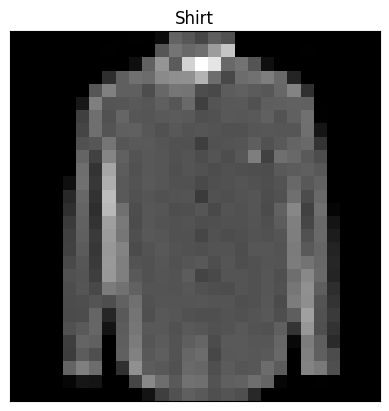

In [15]:
random_idx = torch.randint(0, len(train_data), size = [1]).item()
print(random_idx)
img, label = train_data[random_idx]
fig.add_subplot(rows, cols, i)
plt.title(classnames[label])
plt.imshow(img.squeeze(), cmap="gray")
plt.xticks([])
plt.yticks([])

In [16]:
flatten_model = nn.Flatten()

x = train_features_batch[0]
x.shape


torch.Size([1, 28, 28])

In [17]:
output = flatten_model(x)

In [18]:
output.shape # single row

torch.Size([1, 784])

In [19]:

from torch import nn

class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)


In [20]:
model_0 = FashionMNISTModelV0(
    input_shape=784,
    hidden_units=10, 
    output_shape=len(classnames)
).to("cpu")



In [21]:
dummy_x = torch.rand([1, 1, 28, 28])
model_0(dummy_x).shape

torch.Size([1, 10])

In [22]:
import requests
from pathlib import Path

if Path('helper_functions.py').is_file():
    print('helper functions.py already exits')
else:
    print("download needed")


helper functions.py already exits


In [23]:
from helper_functions import accuracy_fn


In [24]:
loss_fn = nn.CrossEntropyLoss()
optimizer= torch.optim.SGD(params= model_0.parameters(), lr=0.1)

In [25]:
from timeit import default_timer as timer
def printtraintime(start:float, end: float, device: torch.device=None):
    totaltime= end-start
    print(f"time on cpu : {totaltime:.3f}", )

In [26]:
starttime = timer()
for i in range(1,10000):
    a=2
endtime= timer()
printtraintime(start=starttime, end=endtime)

time on cpu : 0.000


In [34]:


from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start_on_cpu= timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print("epoch ", epoch)
    train_loss = 0
    for batch, (X,y) in enumerate(train_dataloader):
        model_0.train()
        ypred = model_0(X)
        loss = loss_fn(ypred, y)
        train_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if batch % 400 == 0:
            print(f"loocked at: {batch * len(X)}/{len(train_dataloader.dataset)} samples")
    


  0%|          | 0/3 [00:00<?, ?it/s]

epoch  0
loocked at: 0/60000 samples
loocked at: 12800/60000 samples
loocked at: 25600/60000 samples
loocked at: 38400/60000 samples
loocked at: 51200/60000 samples


 33%|███▎      | 1/3 [00:02<00:04,  2.08s/it]

epoch  1
loocked at: 0/60000 samples
loocked at: 12800/60000 samples
loocked at: 25600/60000 samples
loocked at: 38400/60000 samples
loocked at: 51200/60000 samples


 67%|██████▋   | 2/3 [00:04<00:02,  2.12s/it]

epoch  2
loocked at: 0/60000 samples
loocked at: 12800/60000 samples
loocked at: 25600/60000 samples
loocked at: 38400/60000 samples
loocked at: 51200/60000 samples


100%|██████████| 3/3 [00:06<00:00,  2.08s/it]


In [36]:
test_loss = 0.0  # Initialize as float for accumulation
test_acc = 0     # Initialize as integer/float for accumulation
num_batches = 0

s= timer()

model_0.eval()
with torch.inference_mode():
    for X_test, y_test in test_dataloader:
        # 1. Forward pass
        test_pred = model_0(X_test)
        
        # 2. Calculate loss (accumulatively)
        # Note: loss_fn usually returns a scalar loss per batch
        test_loss += loss_fn(test_pred, y_test)
        
        # 3. Calculate accuracy
        # Assuming accuracy_fn returns the accuracy for the current batch
        test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))
        
        num_batches += 1

# --- After the loop, calculate the final average ---
# Average Loss
avg_test_loss = test_loss / num_batches
# Average Accuracy
avg_test_acc = test_acc / num_batches

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {avg_test_acc:.4f}")
e = timer()

printtraintime(s, e)

Test Loss: 0.4847
Test Accuracy: 83.1869
time on cpu : 0.257
